# SMS Chat Analysis


## Import and look over your dataset

In [1]:
import pandas as pd

# Load the SMS dataset into a pandas DataFrame
df = pd.read_csv("clean_nus_sms.csv")

# Display first 5 rows to inspect the data
df.head()

,Unnamed: 0,id,Message,length,country,Date
0,0,10120,Bugis oso near wat...,21,SG,2003/4
1,1,10121,"Go until jurong point, crazy.. Available only ...",111,SG,2003/4
2,2,10122,I dunno until when... Lets go learn pilates...,46,SG,2003/4
3,3,10123,Den only weekdays got special price... Haiz......,140,SG,2003/4
4,4,10124,Meet after lunch la...,22,SG,2003/4


## Project Analysis Plan

This project aims to explore SMS communication patterns using Natural Language Processing techniques.

Planned analyses:

1. Exploratory text analysis
   - Message length distribution
   - Word frequency distribution
   - Common bigrams

2. Sentiment analysis
   - Distribution of positive, negative, and neutral messages
   - Relationship between sentiment and message length

3. Topic modeling
   - Identify common themes using TF-IDF and LDA

4. Text similarity analysis
   - Measure similarity between messages using cosine similarity

5. Part-of-Speech tagging
   - Identify commonly used linguistic patterns

## Data Cleaning

In [2]:
# Check number of rows and columns
df.shape

(48598, 6)

In [3]:
# Check column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48598 entries, 0 to 48597
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  48598 non-null  int64 
 1   id          48598 non-null  int64 
 2   Message     48595 non-null  object
 3   length      48598 non-null  object
 4   country     48598 non-null  object
 5   Date        48598 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.2+ MB


In [4]:
# Count missing values per column
df.isnull().sum()

Unnamed: 0    0
id            0
Message       3
length        0
country       0
Date          0
dtype: int64

In [5]:
# Count duplicate rows
df.duplicated().sum()

0

In [6]:
# Drop unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

In [7]:
# Remove rows where Message is missing
df = df.dropna(subset=["Message"])

In [8]:
# Convert length column to numeric
df["length"] = pd.to_numeric(df["length"], errors="coerce")

In [9]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48595 entries, 0 to 48594
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       48595 non-null  int64  
 1   Message  48595 non-null  object 
 2   length   48591 non-null  float64
 3   country  48595 non-null  object 
 4   Date     48595 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.9+ MB


In [11]:
# Remove rows where length could not be converted
df = df.dropna(subset=["length"])

In [12]:
# Convert length to integer type
df["length"] = df["length"].astype(int)

In [13]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48591 entries, 0 to 48590
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       48591 non-null  int64 
 1   Message  48591 non-null  object
 2   length   48591 non-null  int64 
 3   country  48591 non-null  object
 4   Date     48591 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB


## Selected NLP Models and Techniques

This project applies a combination of classical NLP techniques and probabilistic modeling to analyze SMS communication patterns.

- Regular Expressions (regex) for text parsing and cleaning
- Bag-of-Words representation for word frequency analysis
- N-gram analysis (bigrams) for phrase pattern detection
- TF-IDF vectorization for numerical text representation
- Latent Dirichlet Allocation (LDA) for topic modeling

These techniques were chosen to explore linguistic patterns, extract themes, and uncover hidden structure in SMS communication data.

## Text Preprocessing

In [15]:
import re

# Clean text for NLP processing
def clean_message(text):
    text = str(text).lower()                     # Convert to lowercase
    text = re.sub(r"http\S+|www\.\S+", "", text) # Remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)     # Remove punctuation (keep numbers)
    text = re.sub(r"\s+", " ", text).strip()     # Remove extra spaces
    return text

# Create cleaned text column
df["clean_text"] = df["Message"].apply(clean_message)

# Preview results
df[["Message", "clean_text"]].head(10)

,Message,clean_text
0,Bugis oso near wat...,bugis oso near wat
1,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
2,I dunno until when... Lets go learn pilates...,i dunno until when lets go learn pilates
3,Den only weekdays got special price... Haiz......,den only weekdays got special price haiz cant ...
4,Meet after lunch la...,meet after lunch la
5,m walking in citylink now ü faster come down.....,m walking in citylink now faster come down me ...
6,5 nights...We nt staying at port step liao...T...,5 nights we nt staying at port step liao too ex
7,Hey pple...$700 or $900 for 5 nights...Excelle...,hey pple 700 or 900 for 5 nights excellent loc...
8,Yun ah.the ubi one say if ü wan call by tomorr...,yun ah the ubi one say if wan call by tomorrow...
9,Hey tmr maybe can meet you at yck,hey tmr maybe can meet you at yck


## Exploratory Text Analysis

In [16]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Simple tokenizer (no NLTK required)
def simple_tokenize(text: str):
    return re.findall(r"[a-z0-9]+", str(text).lower())

stop_words = set(ENGLISH_STOP_WORDS)

# Tokenize and remove stopwords
df["tokens"] = df["clean_text"].apply(simple_tokenize)
df["tokens_no_stop"] = df["tokens"].apply(lambda words: [w for w in words if w not in stop_words])

df[["clean_text", "tokens_no_stop"]].head()

,clean_text,tokens_no_stop
0,bugis oso near wat,"[bugis, oso, near, wat]"
1,go until jurong point crazy available only in ...,"[jurong, point, crazy, available, bugis, n, gr..."
2,i dunno until when lets go learn pilates,"[dunno, lets, learn, pilates]"
3,den only weekdays got special price haiz cant ...,"[den, weekdays, got, special, price, haiz, eat..."
4,meet after lunch la,"[meet, lunch, la]"


In [17]:
# Flatten tokens and count word frequency
all_words = [w for tokens in df["tokens_no_stop"] for w in tokens]
word_freq = Counter(all_words)

word_freq.most_common(20)

[('u', 10284),
 ('haha', 6968),
 ('s', 3495),
 ('lol', 3260),
 ('t', 2999),
 ('got', 2541),
 ('m', 2458),
 ('ok', 2440),
 ('just', 2313),
 ('time', 2034),
 ('hahaha', 1822),
 ('okay', 1741),
 ('ur', 1671),
 ('2', 1665),
 ('going', 1566),
 ('le', 1548),
 ('oh', 1517),
 ('hey', 1495),
 ('like', 1446),
 ('think', 1430)]

In [18]:
##Improve Stopword List

# Custom SMS stopwords
sms_stopwords = {
    "u", "ur", "m", "s", "t", "2", "haha", "hahaha", "lol",
    "oh", "hey", "ok", "okay", "just"
}

# Combine with sklearn stopwords
all_stopwords = stop_words.union(sms_stopwords)

# Re-filter tokens
df["tokens_no_stop"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in all_stopwords]
)

# Recalculate word frequencies
all_words = [w for tokens in df["tokens_no_stop"] for w in tokens]
word_freq = Counter(all_words)

word_freq.most_common(20)

[('got', 2541),
 ('time', 2034),
 ('going', 1566),
 ('le', 1548),
 ('like', 1446),
 ('think', 1430),
 ('ll', 1429),
 ('come', 1395),
 ('yeah', 1343),
 ('home', 1322),
 ('know', 1318),
 ('good', 1313),
 ('need', 1285),
 ('later', 1245),
 ('dun', 1212),
 ('want', 1204),
 ('hi', 1159),
 ('sorry', 1153),
 ('d', 1146),
 ('meet', 1137)]

### Word Frequency Insights

After removing standard and SMS-specific stopwords, the most frequent terms suggest that SMS communication is primarily used for:

- Coordinating plans (meet, time, later, come)
- Casual social interaction (yeah, sorry, good)
- Informal conversational language

The dataset reflects highly informal and conversational English, including regional shorthand expressions.

In [19]:
#Bigram Analysis

from collections import Counter

# Create bigrams
bigrams = []

for tokens in df["tokens_no_stop"]:
    bigrams.extend(zip(tokens, tokens[1:]))

bigram_freq = Counter(bigrams)

bigram_freq.most_common(20)

[(('let', 'know'), 262),
 (('wat', 'time'), 239),
 (('good', 'morning'), 143),
 (('new', 'year'), 142),
 (('sob', 'sob'), 124),
 (('don', 'know'), 124),
 (('reach', 'home'), 116),
 (('good', 'night'), 109),
 (('o', 'o'), 108),
 (('home', 'le'), 105),
 (('happy', 'birthday'), 104),
 (('dont', 'know'), 100),
 (('x', 'x'), 95),
 (('dun', 'want'), 93),
 (('k', 'k'), 84),
 (('happy', 'new'), 82),
 (('decimal', 'pm'), 82),
 (('ya', 'lo'), 81),
 (('bus', 'stop'), 79),
 (('hi', 'andreu'), 76)]

### Bigram Analysis Insights

The most frequent two-word combinations reveal recurring conversational patterns:

- Coordination and planning phrases (e.g., "let know", "wat time", "reach home")
- Social greetings and events (e.g., "good morning", "happy birthday", "new year")
- Informal and regional SMS shorthand (e.g., "dun want", "ya lo")

This confirms that SMS communication in the dataset is primarily informal, social, and coordination-focused.

## Topic Modeling (LDA)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [21]:
# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(
    max_df=0.95,             # Ignore extremely common words
    min_df=5,                # Ignore rare words
    stop_words=list(all_stopwords)  # sklearn needs a list, not a set
)

tfidf = vectorizer.fit_transform(df["clean_text"])
tfidf.shape

(48591, 5475)

In [22]:
# Train LDA model
lda = LatentDirichletAllocation(
    n_components=5,     # Number of topics
    random_state=42
)

lda.fit(tfidf)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [23]:
# Display top words for each topic
feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx + 1}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        print(", ".join(top_words))

display_topics(lda, feature_names, 10)


Topic 1:
free, decimal, meet, wait, ll, ha, know, leave, hai, min

Topic 2:
dear, love, sure, happy, good, da, doing, come, hee, way

Topic 3:
hi, coming, home, time, soon, later, bus, yo, tmr, meet

Topic 4:
yeah, got, like, going, yes, think, need, dun, ask, la

Topic 5:
thanks, ya, yup, eat, sorry, dinner, buy, eh, got, le


## Topic Modeling (LDA) Results

Using Latent Dirichlet Allocation (LDA) with 5 topics, the following themes were identified:

**Topic 1 – Availability & Logistics**
Words: free, meet, wait, leave, min  
This topic reflects scheduling and coordination-related conversations.

**Topic 2 – Affection & Friendly Conversation**
Words: dear, love, happy, good, sure  
Represents emotionally expressive and friendly interactions.

**Topic 3 – Meetups & Transportation Planning**
Words: coming, home, time, bus, meet  
Strongly associated with planning meetings and transportation.

**Topic 4 – General Informal Discussion**
Words: yeah, got, going, think, need  
Captures informal conversational responses and opinions.

**Topic 5 – Food & Casual Social Interaction**
Words: thanks, eat, dinner, buy, sorry  
Represents social interactions often centered around meals.

In [24]:
# Get topic probabilities for each message
topic_values = lda.transform(tfidf)

# Assign dominant topic
df["dominant_topic"] = topic_values.argmax(axis=1)

df[["clean_text", "dominant_topic"]].head()

,clean_text,dominant_topic
0,bugis oso near wat,4
1,go until jurong point crazy available only in ...,4
2,i dunno until when lets go learn pilates,4
3,den only weekdays got special price haiz cant ...,4
4,meet after lunch la,2


In [25]:
# Count messages per topic
df["dominant_topic"].value_counts()

dominant_topic
3    11328
4    10064
0     9289
1     9052
2     8858
Name: count, dtype: int64

### Topic Distribution Analysis

After assigning the dominant topic to each message, the distribution of topics was analyzed.

The most frequent topic corresponds to coordination and meetup-related conversations, confirming that SMS is primarily used for logistical planning.

The remaining topics are relatively balanced, indicating diverse conversational themes including informal discussion, affection, and social interaction.

This balanced distribution suggests that the dataset represents authentic conversational communication rather than a single-purpose messaging pattern.

## Sentiment Analysis

In [26]:
import sys
!{sys.executable} -m pip install textblob


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
from textblob import TextBlob

In [31]:


# Calculate sentiment polarity
df["sentiment"] = df["clean_text"].apply(lambda x: TextBlob(x).sentiment.polarity)

df[["clean_text", "sentiment"]].head()

,clean_text,sentiment
0,bugis oso near wat,0.100000
1,go until jurong point crazy available only in ...,0.150000
2,i dunno until when lets go learn pilates,0.000000
3,den only weekdays got special price haiz cant ...,0.178571
4,meet after lunch la,0.000000


In [32]:
def categorize_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment"].apply(categorize_sentiment)

df["sentiment_label"].value_counts()


sentiment_label
Neutral     23902
Positive    19299
Negative     5390
Name: count, dtype: int64

### Sentiment by Topic

In [33]:
## Create a Topic Name Map (so it’s readable)

# Human-readable topic names (based on your LDA output)
topic_names = {
    0: "Topic 1 – Availability & Logistics",
    1: "Topic 2 – Affection & Friendly Conversation",
    2: "Topic 3 – Meetups & Transportation Planning",
    3: "Topic 4 – General Informal Discussion",
    4: "Topic 5 – Food & Casual Social Interaction"
}

df["topic_name"] = df["dominant_topic"].map(topic_names)

df[["clean_text", "dominant_topic", "topic_name", "sentiment_label"]].head()

,clean_text,dominant_topic,topic_name,sentiment_label
0,bugis oso near wat,4,Topic 5 – Food & Casual Social Interaction,Positive
1,go until jurong point crazy available only in ...,4,Topic 5 – Food & Casual Social Interaction,Positive
2,i dunno until when lets go learn pilates,4,Topic 5 – Food & Casual Social Interaction,Neutral
3,den only weekdays got special price haiz cant ...,4,Topic 5 – Food & Casual Social Interaction,Positive
4,meet after lunch la,2,Topic 3 – Meetups & Transportation Planning,Neutral


In [34]:
# Count sentiment labels within each topic
sentiment_by_topic_counts = pd.crosstab(df["topic_name"], df["sentiment_label"])

sentiment_by_topic_counts

sentiment_label,Negative,Neutral,Positive
topic_name,,,
Topic 1 – Availability & Logistics,690,6247,2352
Topic 2 – Affection & Friendly Conversation,881,3990,4181
Topic 3 – Meetups & Transportation Planning,954,4815,3089
Topic 4 – General Informal Discussion,1559,4551,5218
Topic 5 – Food & Casual Social Interaction,1306,4299,4459


In [35]:
# Convert counts to row-wise percentages
sentiment_by_topic_pct = sentiment_by_topic_counts.div(sentiment_by_topic_counts.sum(axis=1), axis=0) * 100
sentiment_by_topic_pct.round(2)

sentiment_label,Negative,Neutral,Positive
topic_name,,,
Topic 1 – Availability & Logistics,7.43,67.25,25.32
Topic 2 – Affection & Friendly Conversation,9.73,44.08,46.19
Topic 3 – Meetups & Transportation Planning,10.77,54.36,34.87
Topic 4 – General Informal Discussion,13.76,40.17,46.06
Topic 5 – Food & Casual Social Interaction,12.98,42.72,44.31


In [36]:
# Average sentiment polarity per topic
df.groupby("topic_name")["sentiment"].mean().sort_values(ascending=False)

topic_name
Topic 2 – Affection & Friendly Conversation    0.163615
Topic 4 – General Informal Discussion          0.115029
Topic 5 – Food & Casual Social Interaction     0.109045
Topic 3 – Meetups & Transportation Planning    0.091450
Topic 1 – Availability & Logistics             0.079403
Name: sentiment, dtype: float64

### Sentiment and Topic Interaction Insights

By combining topic modeling with sentiment analysis, we observed distinct emotional patterns across communication themes:

- **Affection & Friendly Conversation** exhibits the highest positive sentiment.
- **General Informal Discussion** is also strongly positive.
- **Availability & Logistics** messages are predominantly neutral, reflecting practical coordination.
- Social themes (food, meetups, greetings) tend to lean positive overall.

These findings suggest that SMS communication is primarily practical and coordination-driven, but social themes contribute significantly to positive emotional tone.

## Visualization: Topics Ranked by Positive Sentiment

To better understand how emotional tone varies across conversational themes, topics were ranked based on the percentage of positive sentiment detected within each group.

The chart below displays the proportion of positive messages for each topic identified by the LDA model.

### Key Observations

- **Affection & Friendly Conversation** shows the highest level of positive sentiment.
- **General Informal Discussion** also demonstrates a strongly positive tone.
- **Food & Casual Social Interaction** is moderately positive.
- **Meetups & Transportation Planning** tends to be more neutral.
- **Availability & Logistics** is the least positive and largely neutral in tone.

### Interpretation

These results suggest that:
- Emotionally expressive and socially driven conversations are more positive.
- Coordination and logistical messages are primarily neutral.
- Social interactions (food, greetings, casual chat) contribute significantly to overall positivity in SMS communication.

This ranking provides a clearer understanding of how emotional patterns vary across communication themes.

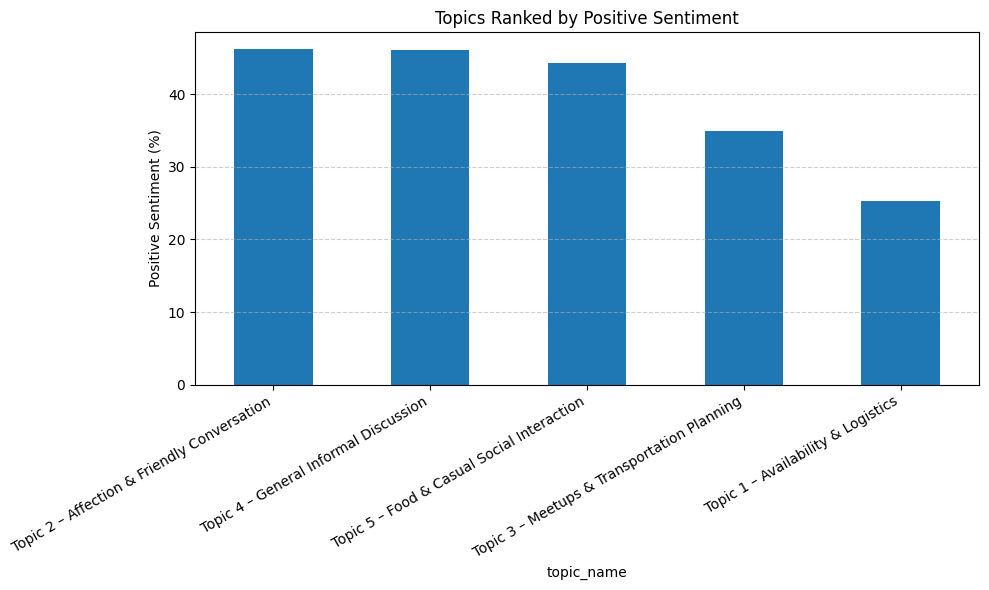

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sorted_topics["Positive"].plot(kind="bar")

plt.title("Topics Ranked by Positive Sentiment")
plt.ylabel("Positive Sentiment (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()